# Board Games Dataset Summary
**Dataset:** [Board Games Database from BoardGameGeek](https://www.kaggle.com/datasets/threnjen/board-games-database-from-boardgamegeek)

Basic Info about the dataset
1. Interaction matrix sparsity
2. Ratings per user (cold-start problem)
3. Game popularity & long-tail distribution

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
path = kagglehub.dataset_download("threnjen/board-games-database-from-boardgamegeek")
print(f"Path to dataset files: {path}")

games = pd.read_csv(f"{path}/games.csv")
user_ratings = pd.read_csv(f"{path}/user_ratings.csv")
mechanics = pd.read_csv(f"{path}/mechanics.csv")
subcategories = pd.read_csv(f"{path}/subcategories.csv")

print(f"games: {games.shape}")
print(f"user_ratings: {user_ratings.shape}")
print(f"mechanics: {mechanics.shape}")
print(f"subcategories: {subcategories.shape}")

Path to dataset files: /Users/bush/.cache/kagglehub/datasets/threnjen/board-games-database-from-boardgamegeek/versions/4
games: (21925, 48)
user_ratings: (18942215, 3)
mechanics: (21925, 158)
subcategories: (21925, 11)


## Initial EDA

In [3]:
games.head()

,BGGId,Name,Description,YearPublished,GameWeight,AvgRating,BayesAvgRating,StdDev,MinPlayers,MaxPlayers,...,Rank:partygames,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens
0,1,Die Macher,die macher game seven sequential political rac...,1986,4.3206,7.61428,7.10363,1.57979,3,5,...,21926,21926,0,1,0,0,0,0,0,0
1,2,Dragonmaster,dragonmaster tricktaking card game base old ga...,1981,1.9630,6.64537,5.78447,1.45440,3,4,...,21926,21926,0,1,0,0,0,0,0,0
2,3,Samurai,samurai set medieval japan player compete gain...,1998,2.4859,7.45601,7.23994,1.18227,2,4,...,21926,21926,0,1,0,0,0,0,0,0
3,4,Tal der Könige,triangular box luxurious large block tal der k...,1992,2.6667,6.60006,5.67954,1.23129,2,4,...,21926,21926,0,0,0,0,0,0,0,0
4,5,Acquire,acquire player strategically invest business t...,1964,2.5031,7.33861,7.14189,1.33583,2,6,...,21926,21926,0,1,0,0,0,0,0,0


We can see theres an extra coloumn BGGId that is essentially the board game's index offset by one. We should remove this later since its value has no significance.

In [4]:
games.dtypes

BGGId                    int64
Name                       str
Description                str
YearPublished            int64
GameWeight             float64
AvgRating              float64
BayesAvgRating         float64
StdDev                 float64
MinPlayers               int64
MaxPlayers               int64
ComAgeRec              float64
LanguageEase           float64
BestPlayers              int64
GoodPlayers                str
NumOwned                 int64
NumWant                  int64
NumWish                  int64
NumWeightVotes           int64
MfgPlaytime              int64
ComMinPlaytime           int64
ComMaxPlaytime           int64
MfgAgeRec                int64
NumUserRatings           int64
NumComments              int64
NumAlternates            int64
NumExpansions            int64
NumImplementations       int64
IsReimplementation       int64
Family                     str
Kickstarted              int64
ImagePath                  str
Rank:boardgame           int64
Rank:str

In [5]:
games.isnull().sum()

BGGId                      0
Name                       0
Description                1
YearPublished              0
GameWeight                 0
AvgRating                  0
BayesAvgRating             0
StdDev                     0
MinPlayers                 0
MaxPlayers                 0
ComAgeRec               5530
LanguageEase            5891
BestPlayers                0
GoodPlayers                0
NumOwned                   0
NumWant                    0
NumWish                    0
NumWeightVotes             0
MfgPlaytime                0
ComMinPlaytime             0
ComMaxPlaytime             0
MfgAgeRec                  0
NumUserRatings             0
NumComments                0
NumAlternates              0
NumExpansions              0
NumImplementations         0
IsReimplementation         0
Family                 15262
Kickstarted                0
ImagePath                 17
Rank:boardgame             0
Rank:strategygames         0
Rank:abstracts             0
Rank:familygam

We can see that several columns have many missing values like `Family`, `ComAgeRec`, and `LanguageEase` being in the thousands. Two other columns with significantly less missing values would be `Description` and `ImagePath`. With **21925** rows of data in the dataset, a column like Family missing **15262** is quite significant making up around 70% of the dataset. This means we need to investigate the significance of these columns, and either drop them, or augment the data to fill in the values since removing 70% of the rows would effect the performance of the model.

In [6]:
games.columns

Index(['BGGId', 'Name', 'Description', 'YearPublished', 'GameWeight',
       'AvgRating', 'BayesAvgRating', 'StdDev', 'MinPlayers', 'MaxPlayers',
       'ComAgeRec', 'LanguageEase', 'BestPlayers', 'GoodPlayers', 'NumOwned',
       'NumWant', 'NumWish', 'NumWeightVotes', 'MfgPlaytime', 'ComMinPlaytime',
       'ComMaxPlaytime', 'MfgAgeRec', 'NumUserRatings', 'NumComments',
       'NumAlternates', 'NumExpansions', 'NumImplementations',
       'IsReimplementation', 'Family', 'Kickstarted', 'ImagePath',
       'Rank:boardgame', 'Rank:strategygames', 'Rank:abstracts',
       'Rank:familygames', 'Rank:thematic', 'Rank:cgs', 'Rank:wargames',
       'Rank:partygames', 'Rank:childrensgames', 'Cat:Thematic',
       'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS', 'Cat:Abstract',
       'Cat:Party', 'Cat:Childrens'],
      dtype='str')

Now investigating the columns in question and more.

In [7]:
games[['Family', 'ComAgeRec', 'LanguageEase', 'Description', "ImagePath"]]

,Family,ComAgeRec,LanguageEase,Description,ImagePath
0,Classic Line (Valley Games),14.366667,1.395833,die macher game seven sequential political rac...,https://cf.geekdo-images.com/rpwCZAjYLD940NWwP...
1,NaN,NaN,27.000000,dragonmaster tricktaking card game base old ga...,https://cf.geekdo-images.com/oQYhaJx5Lg3KcGis2...
2,Euro Classics (Reiner Knizia),9.307692,1.000000,samurai set medieval japan player compete gain...,https://cf.geekdo-images.com/o9-sNXmFS_TLAb7Zl...
3,NaN,13.000000,256.000000,triangular box luxurious large block tal der k...,https://cf.geekdo-images.com/nYiYhUlatT2DpyXaJ...
4,3M Bookshelf,11.410256,21.152941,acquire player strategically invest business t...,https://cf.geekdo-images.com/3C--kJRhi6kTPHsr9...
...,...,...,...,...,...
21920,NaN,12.000000,NaN,oil tanker fire rescue team send deal damage...,https://cf.geekdo-images.com/Uzx3n6dd0LGC2sGyS...
21921,NaN,16.000000,98.000000,new square edition include nippon expansion up...,https://cf.geekdo-images.com/eG4UBkwA9SNNEFUkE...
21922,NaN,12.000000,155.000000,million year people force play timehonored gam...,https://cf.geekdo-images.com/TRCPgnDKCu8civrbB...
21923,NaN,NaN,31.000000,splitter group number score point mdash s s md...,https://cf.geekdo-images.com/6ILh7aNVHosY-m5gG...


Because the actual value contained inside `ImagePath` is not significant, we will just remove that column since each boardgame will have its own unique link. However, we could potentially revist this column and take advantage of a CNN to predict if the cover iamge of a game relates to whether a game receives higher reviews similar to Netflix. The `Description` column is similar in that all rows will have a unique entry and will be dropped, but an llm could potentially be integrated to parse the description and create relavent tags. `Names` is irrelavent and will be dropped completely.

In [8]:
# Count unique entries in the family column
family_counts = games['Family'].value_counts()
print(family_counts)
print("")
print(family_counts.describe())


Family
18xx                                                  103
Monopoly (Official)                                    73
Trivial Pursuit                                        67
Werewolf / Mafi                                        58
Wallet Games (Button Shy)                              45
                                                     ... 
Holiday Hijinks (Grand Gamers Guild)                    1
WWII Battle Series (Three Crowns Game Productions)      1
Five Parsecs (Nordic Weasel Games)                      1
Great Western Trail                                     1
Smartphone Inc.                                         1
Name: count, Length: 1456, dtype: int64

count    1456.000000
mean        4.576236
std         6.584452
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       103.000000
Name: count, dtype: float64


Because thare are about 1456 categories, with the top category `18xx` labeling **103** of the **21925** board games in the dataset, it wouldn't be practical to agument the other **70%** of the column if the current labels don't do a good job of representing the games. Therefore we will choose to drop this column as well.

array([[<Axes: title={'center': 'Rank:boardgame'}>,
        <Axes: title={'center': 'Rank:strategygames'}>,
        <Axes: title={'center': 'Rank:abstracts'}>],
       [<Axes: title={'center': 'Rank:familygames'}>,
        <Axes: title={'center': 'Rank:thematic'}>,
        <Axes: title={'center': 'Rank:cgs'}>],
       [<Axes: title={'center': 'Rank:wargames'}>,
        <Axes: title={'center': 'Rank:partygames'}>,
        <Axes: title={'center': 'Rank:childrensgames'}>]], dtype=object)

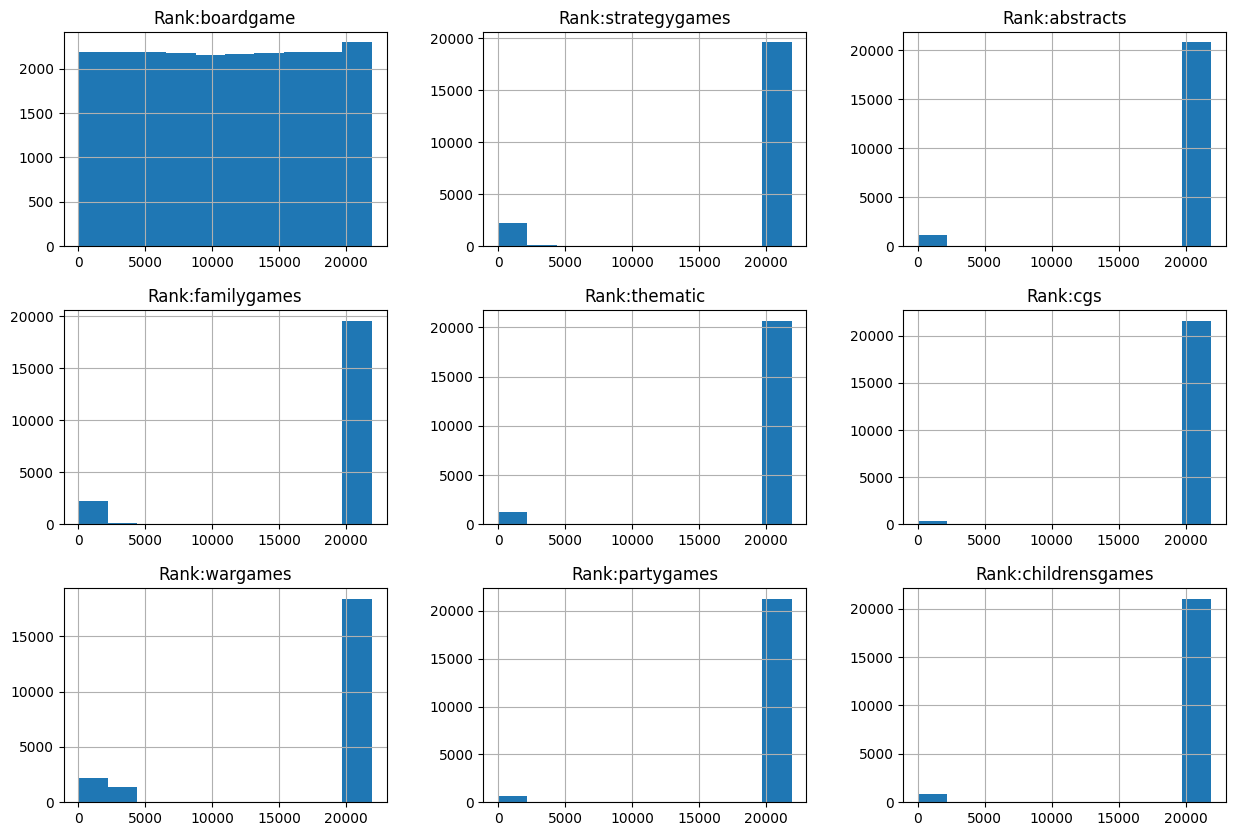

In [9]:
games[['Rank:boardgame', 'Rank:strategygames', 'Rank:abstracts',
       'Rank:familygames', 'Rank:thematic', 'Rank:cgs', 'Rank:wargames',
       'Rank:partygames', 'Rank:childrensgames']].hist(figsize=(15, 10))

array([[<Axes: title={'center': 'Cat:Thematic'}>,
        <Axes: title={'center': 'Cat:Strategy'}>,
        <Axes: title={'center': 'Cat:War'}>],
       [<Axes: title={'center': 'Cat:Family'}>,
        <Axes: title={'center': 'Cat:CGS'}>,
        <Axes: title={'center': 'Cat:Abstract'}>],
       [<Axes: title={'center': 'Cat:Party'}>,
        <Axes: title={'center': 'Cat:Childrens'}>, <Axes: >]],
      dtype=object)

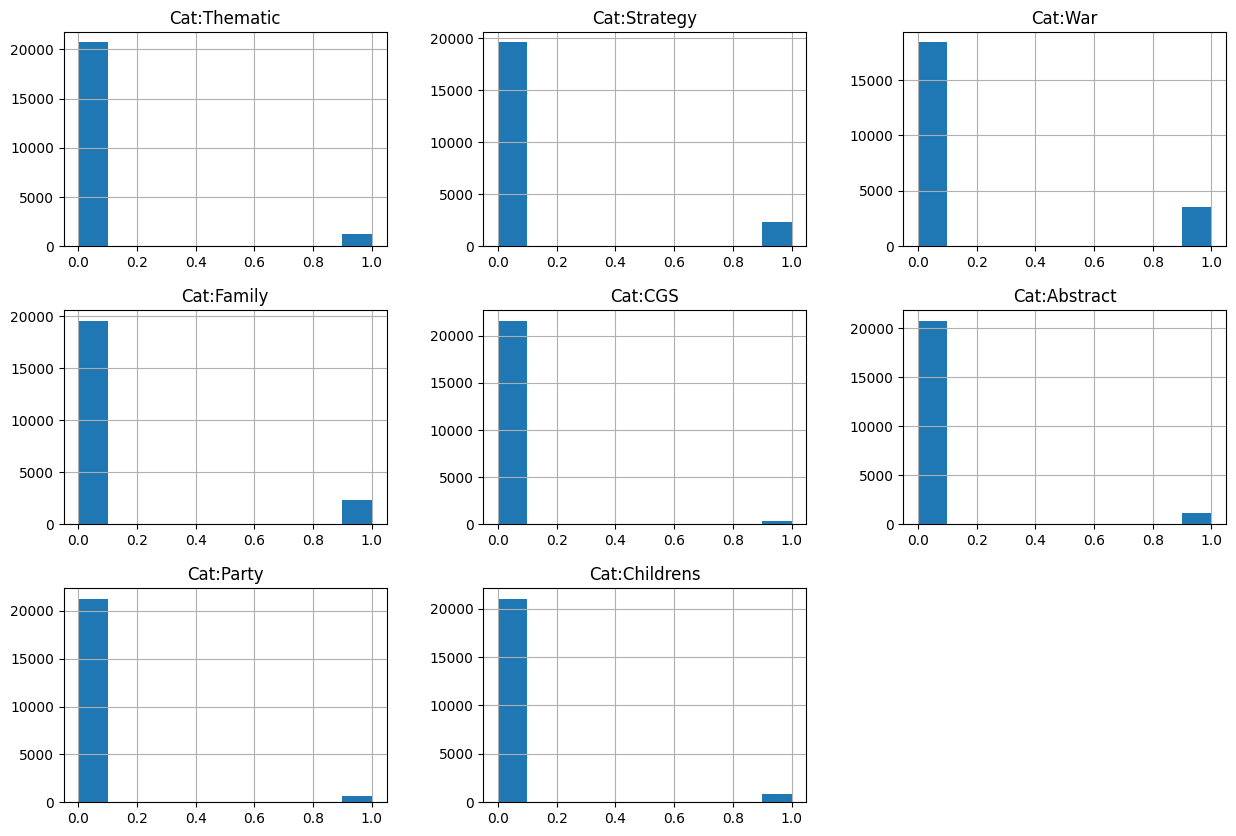

In [10]:
games[['Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family',
       'Cat:CGS', 'Cat:Abstract', 'Cat:Party', 'Cat:Childrens']].hist(figsize=(15, 10))

All the categories and ranks for the games are essentially bool values that tell whether the game is apart of that category or not with the exception of `Rank:boardgame`. I assume that the tags seperated a one hot encoding of the catergories and ranks into seperate columns. In our case we can simple normalize the data to 1s and 0s for better model training.

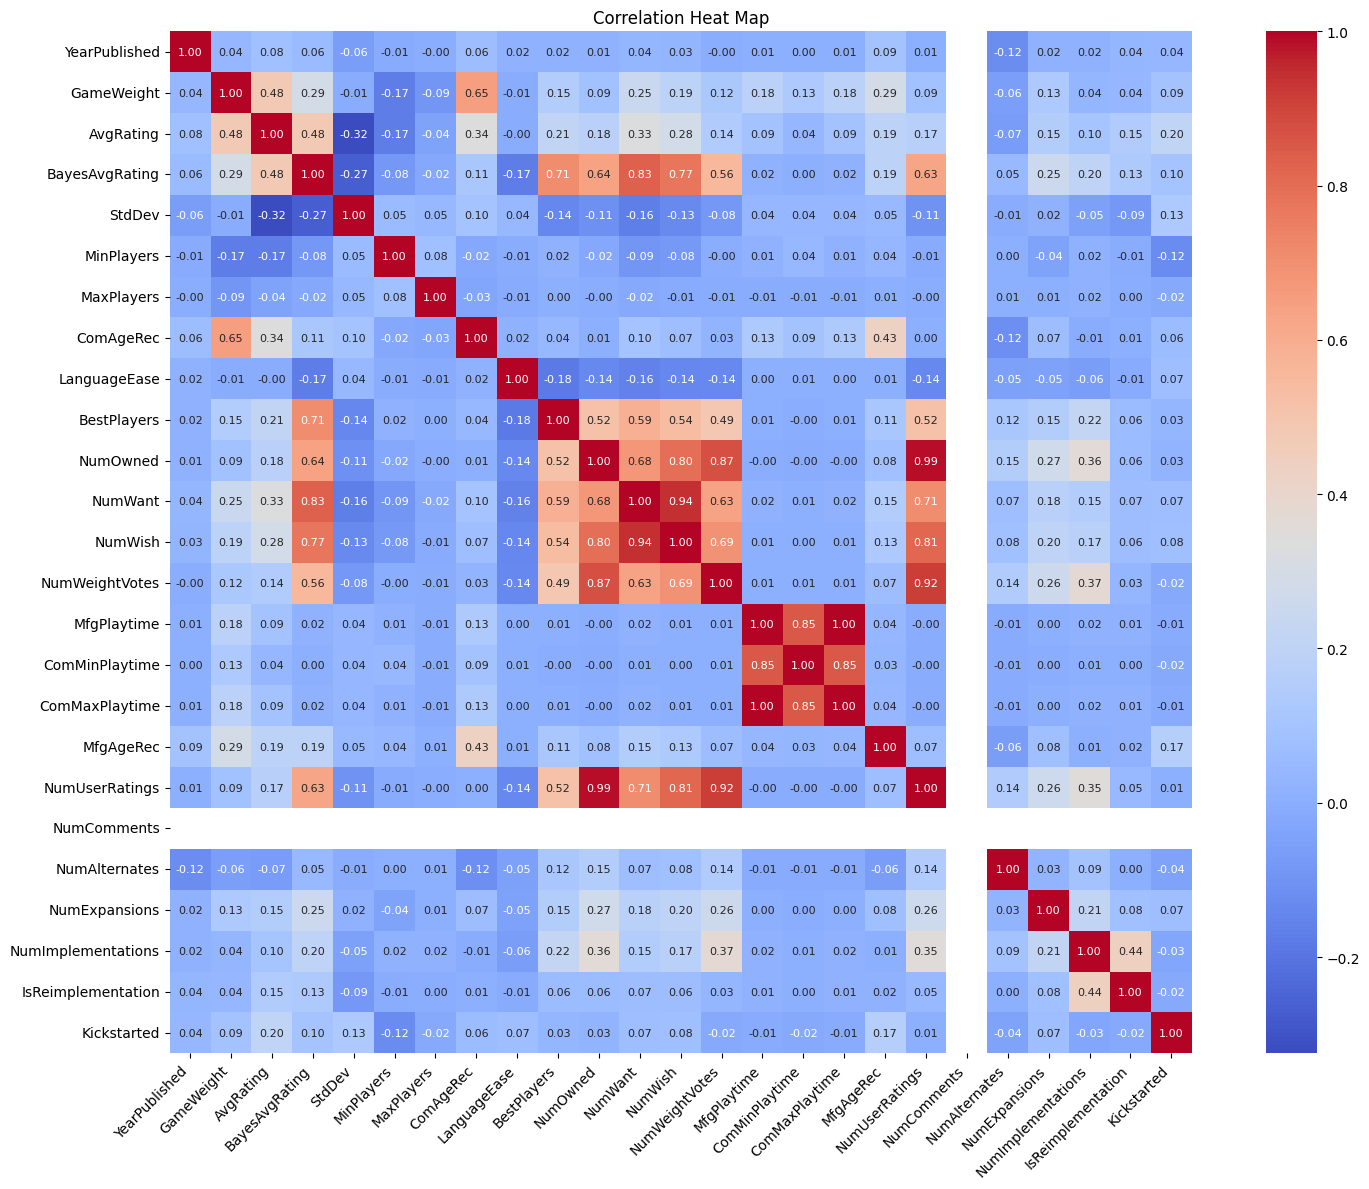

In [11]:
numerical_data = games[['YearPublished', 'GameWeight',
       'AvgRating', 'BayesAvgRating', 'StdDev', 'MinPlayers', 'MaxPlayers',
       'ComAgeRec', 'LanguageEase', 'BestPlayers', 'NumOwned',
       'NumWant', 'NumWish', 'NumWeightVotes', 'MfgPlaytime', 'ComMinPlaytime',
       'ComMaxPlaytime', 'MfgAgeRec', 'NumUserRatings', 'NumComments',
       'NumAlternates', 'NumExpansions', 'NumImplementations',
       'IsReimplementation', 'Kickstarted']]

plt.figure(figsize=(16, 12))

correlationMap = numerical_data.corr(method='pearson')

sns.heatmap(
    correlationMap,
    square=True,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    cmap="coolwarm"
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title("Correlation Heat Map")
plt.tight_layout()
plt.show()

## 1. Sparsity

In [12]:
n_users = user_ratings['Username'].nunique()
n_games = user_ratings['BGGId'].nunique()
n_ratings = len(user_ratings)
n_possible = n_users * n_games
sparsity = 1 - n_ratings / n_possible
summary = pd.DataFrame({
    "Metric": ["Unique users", "Unique games", "Total ratings", "Possible cells", "Sparsity"],
    "Value":  [f"{n_users:,}", f"{n_games:,}", f"{n_ratings:,}", f"{n_possible:,}", f"{sparsity*100:.2f}%"]
})
summary.set_index("Metric")

,Value
Metric,
Unique users,"411,374"
Unique games,"21,925"
Total ratings,"18,942,215"
Possible cells,"9,019,374,950"
Sparsity,99.79%


## 2. Ratings Per User (Cold-Start Signal)

Ratings per user — summary stats
count    411374.000000
mean         46.046060
std         108.431797
min           1.000000
25%           2.000000
50%          12.000000
75%          44.000000
max        6493.000000

Threshold              % of users
<= 5                        36.7%
<= 10                       47.2%
<= 20                       59.9%
<= 50                       77.6%
<= 100                      88.4%


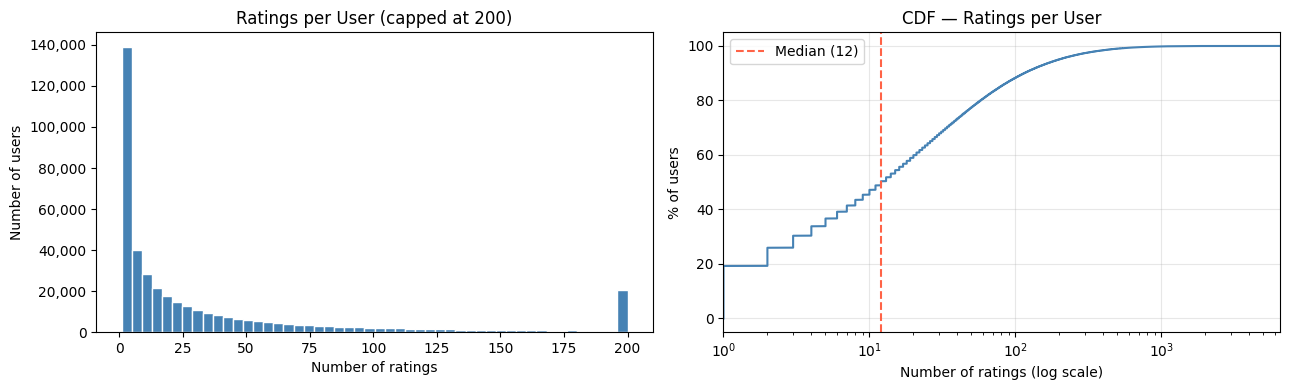

In [13]:
ratings_per_user = user_ratings.groupby('Username').size()

print("Ratings per user — summary stats")
print(ratings_per_user.describe().rename("ratings/user").to_string())
print()

thresholds = [5, 10, 20, 50, 100]
print(f"{'Threshold':<20} {'% of users':>12}")
for t in thresholds:
    pct = (ratings_per_user <= t).mean() * 100
    print(f"<= {t:<17} {pct:>11.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ratings_per_user.clip(upper=200), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Ratings per User (capped at 200)")
axes[0].set_xlabel("Number of ratings")
axes[0].set_ylabel("Number of users")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

sorted_vals = np.sort(ratings_per_user.values)
cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
axes[1].plot(sorted_vals, cdf * 100, color='steelblue', linewidth=1.5)
axes[1].set_xscale('log')
axes[1].set_xlim(1, sorted_vals.max())
axes[1].set_xlabel("Number of ratings (log scale)")
axes[1].set_ylabel("% of users")
axes[1].set_title("CDF — Ratings per User")
axes[1].axvline(12, color='tomato', linestyle='--', label='Median (12)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Game popularity & long-tail distribution

Top 10 most-rated games:


,Ratings,% of all
Game,,
Pandemic,107760,0.569
Carcassonne,107601,0.568
Catan,106725,0.563
7 Wonders,89014,0.470
Dominion,80901,0.427
Ticket to Ride,75352,0.398
Codenames,73188,0.386
Terraforming Mars,72753,0.384
7 Wonders Duel,68063,0.359



Top  1% of games ( 219 titles) → 33.8% of all ratings
Top 10% of games (2192 titles) → 76.7% of all ratings

Games with  <50 ratings : 19.9%
Games with <100 ratings : 43.9%

Catan: 106,725 ratings  (0.563% of all)
Pandemic: 107,760 ratings  (0.569% of all)


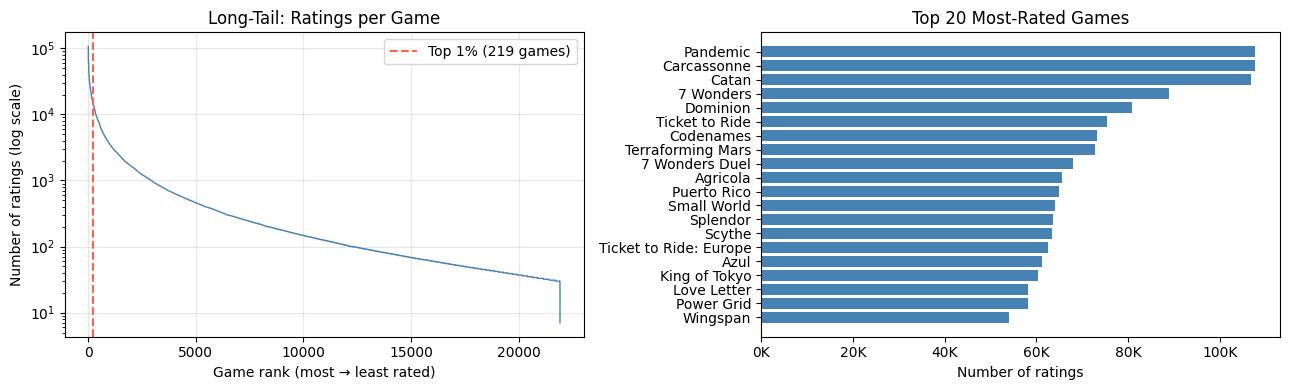

In [14]:
ratings_per_game = user_ratings.groupby('BGGId').size().sort_values(ascending=False)
total_ratings = ratings_per_game.sum()
game_names = games.set_index('BGGId')['Name']

top10 = ratings_per_game.head(10).reset_index()
top10.columns = ['BGGId', 'Ratings']
top10['Game'] = top10['BGGId'].map(game_names)
top10['% of all'] = (top10['Ratings'] / total_ratings * 100).round(3)
print("Top 10 most-rated games:")
display(top10[['Game', 'Ratings', '% of all']].set_index('Game'))

top_1pct = int(len(ratings_per_game) * 0.01)
top_10pct = int(len(ratings_per_game) * 0.10)
print(f"\nTop  1% of games ({top_1pct:>4} titles) → {ratings_per_game.head(top_1pct).sum()/total_ratings*100:.1f}% of all ratings")
print(f"Top 10% of games ({top_10pct:>4} titles) → {ratings_per_game.head(top_10pct).sum()/total_ratings*100:.1f}% of all ratings")
print(f"\nGames with  <50 ratings : {(ratings_per_game <  50).mean()*100:.1f}%")
print(f"Games with <100 ratings : {(ratings_per_game < 100).mean()*100:.1f}%\n")

for target in ['Catan', 'Pandemic']:
    bid = games[games['Name'] == target]['BGGId'].values[0]
    cnt = ratings_per_game.get(bid, 0)
    print(f"{target}: {cnt:,} ratings  ({cnt/total_ratings*100:.3f}% of all)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, len(ratings_per_game) + 1), ratings_per_game.values, color='steelblue', linewidth=1)
axes[0].set_yscale('log')
axes[0].set_xlabel("Game rank (most → least rated)")
axes[0].set_ylabel("Number of ratings (log scale)")
axes[0].set_title("Long-Tail: Ratings per Game")
axes[0].axvline(top_1pct, color='tomato', linestyle='--', label=f'Top 1% ({top_1pct} games)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

top20_names = [game_names.get(i, f"ID {i}") for i in ratings_per_game.head(20).index]
top20_vals  = ratings_per_game.head(20).values
axes[1].barh(top20_names[::-1], top20_vals[::-1], color='steelblue')
axes[1].set_xlabel("Number of ratings")
axes[1].set_title("Top 20 Most-Rated Games")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))

plt.tight_layout()
plt.show()

## 4. Baseline Models

Two baselines evaluated on RMSE and MAE:

| Model | Description |
|-------|-------------|
| **Popularity** | Recommend top-N most-rated games to all users; predict with per-game mean rating |
| **User-Based KNN** | Find k most similar users via cosine similarity; predict as weighted average of their ratings |

### Train / Test Split

In [15]:
from sklearn.model_selection import train_test_split

min_ratings = 5
active_users = user_ratings.groupby('Username').filter(lambda x: len(x) >= min_ratings)
print(f"Ratings after filtering users with <{min_ratings} ratings: {len(active_users):,}")
print(f"Users remaining: {active_users['Username'].nunique():,}")

# 80/20 split
train, test = train_test_split(active_users, test_size=0.2, random_state=42)
print(f"\nTrain size : {len(train):,}")
print(f"Test size : {len(test):,}")

global_mean = train['Rating'].mean()
print(f"\nGlobal mean (train): {global_mean:.4f}")

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

Ratings after filtering users with <5 ratings: 18,696,365
Users remaining: 272,184

Train size : 14,957,092
Test size : 3,739,273

Global mean (train): 7.1118


### Baseline 1: Popularity-Based Ranking

In [16]:
game_mean = train.groupby('BGGId')['Rating'].mean()

preds_pop = test['BGGId'].map(game_mean).fillna(global_mean)
rmse_pop = rmse(test['Rating'], preds_pop)
mae_pop = mae(test['Rating'],  preds_pop)

print(f"Popularity baseline (per-game mean)")
print(f"RMSE : {rmse_pop:.4f}")
print(f"MAE : {mae_pop:.4f}")

print("\nTop 10 games to recommend (by number of train ratings):")
top_pop = (train.groupby('BGGId')
               .agg(n_ratings=('Rating','count'), avg_rating=('Rating','mean'))
               .sort_values('n_ratings', ascending=False)
               .head(10))
top_pop['Name'] = top_pop.index.map(game_names)
display(top_pop[['Name','n_ratings','avg_rating']].reset_index(drop=True))

Popularity baseline (per-game mean)
RMSE : 1.3196
MAE : 1.0012

Top 10 games to recommend (by number of train ratings):


,Name,n_ratings,avg_rating
0,Pandemic,84389,7.638829
1,Carcassonne,83985,7.454927
2,Catan,82495,7.170982
3,7 Wonders,69947,7.780845
4,Dominion,63548,7.647983
5,Ticket to Ride,59363,7.456481
6,Codenames,57950,7.675544
7,Terraforming Mars,55356,8.505254
8,7 Wonders Duel,53136,8.183961
9,Agricola,51356,7.971187


### Baseline 2: User-Based Collaborative Filtering (KNNBasic)

Implements the same algorithm as `surprise.KNNBasic`:
- Build a sparse user-item ratings matrix
- Compute user-user **cosine similarity**
- Predict as the **weighted average** of the k nearest neighbors who rated that item
- Falls back to global mean when no neighbor overlap exists

In [17]:
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder

MIN_RATINGS_KNN = 20
active = train.groupby('Username').filter(lambda x: len(x) >= MIN_RATINGS_KNN)
print(f"Users with >= {MIN_RATINGS_KNN} train ratings: {active['Username'].nunique():,}")

SAMPLE_USERS = 15_000
np.random.seed(42)
sampled_users = np.random.choice(active['Username'].unique(), size=SAMPLE_USERS, replace=False)
sample_train = active[active['Username'].isin(sampled_users)]
print(f"Sampled {SAMPLE_USERS:,} users  |  {len(sample_train):,} ratings")

user_enc = LabelEncoder().fit(sample_train['Username'])
game_enc = LabelEncoder().fit(sample_train['BGGId'])

u_idx = user_enc.transform(sample_train['Username'])
g_idx = game_enc.transform(sample_train['BGGId'])

n_users_knn = len(user_enc.classes_)
n_games_knn = len(game_enc.classes_)

R = csr_matrix(
    (sample_train['Rating'].values, (u_idx, g_idx)),
    shape=(n_users_knn, n_games_knn)
)
print(f"\nSparse matrix shape : {R.shape}")
print(f"Stored values : {R.nnz:,}")

Users with >= 20 train ratings: 150,634
Sampled 15,000 users  |  1,350,517 ratings

Sparse matrix shape : (15000, 21538)
Stored values : 1,348,330


In [18]:
from sklearn.metrics.pairwise import cosine_similarity

#Compute user-user cosine similarity
sim_matrix = cosine_similarity(R)  
np.fill_diagonal(sim_matrix, 0)     
print(f"Similarity matrix shape: {sim_matrix.shape}")

Similarity matrix shape: (15000, 15000)


In [19]:
from scipy.sparse import csc_matrix

K = 40  

# To speed up compile run for this cell, we use CSC format for fast column (per-game) slicing 
R_csc = R.tocsc()

# We use dict lookups instead of LabelEncoder.transform() per row to also speed things up
user_to_idx = {u: i for i, u in enumerate(user_enc.classes_)}
game_to_idx = {g: i for i, g in enumerate(game_enc.classes_)}

def predict_knn(username, bgg_id):
    u = user_to_idx.get(username)
    g = game_to_idx.get(bgg_id)
    if u is None or g is None:
        return global_mean

    item_col = R_csc[:, g].toarray().ravel()   
    rated_mask = item_col > 0
    sim_scores = sim_matrix[u] * rated_mask

    top_k_idx = np.argpartition(sim_scores, -K)[-K:]
    top_k_sims = sim_scores[top_k_idx]
    top_k_rates = item_col[top_k_idx]

    denom = top_k_sims.sum()
    if denom == 0:
        return global_mean

    return float(np.clip(np.dot(top_k_sims, top_k_rates) / denom, 1, 10))

test_knn = test[test['Username'].isin(user_to_idx) & test['BGGId'].isin(game_to_idx)]
print(f"Test pairs evaluable by KNN : {len(test_knn):,}  (of {len(test):,} total)")

preds_knn = [predict_knn(row.Username, row.BGGId) for row in test_knn.itertuples()]
rmse_knn = rmse(test_knn['Rating'], preds_knn)
mae_knn = mae(test_knn['Rating'], preds_knn)

print(f"\nUser-Based KNN (k={K})")
print(f"RMSE: {rmse_knn:.4f}")
print(f"MAE: {mae_knn:.4f}")

Test pairs evaluable by KNN : 334,648  (of 3,739,273 total)

User-Based KNN (k=40)
RMSE: 1.3080
MAE: 0.9987


### Results & Key Metrics

,Model,RMSE,MAE
0,User-Based KNN (k=40),1.3080,0.9987
1,Popularity (per-game mean),1.3196,1.0012


/var/folders/cy/409w3plj3vd3ps5d7mt5q4hh0000gn/T/ipykernel_35332/262009120.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results['Model'], rotation=10, ha='right')
/var/folders/cy/409w3plj3vd3ps5d7mt5q4hh0000gn/T/ipykernel_35332/262009120.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results['Model'], rotation=10, ha='right')


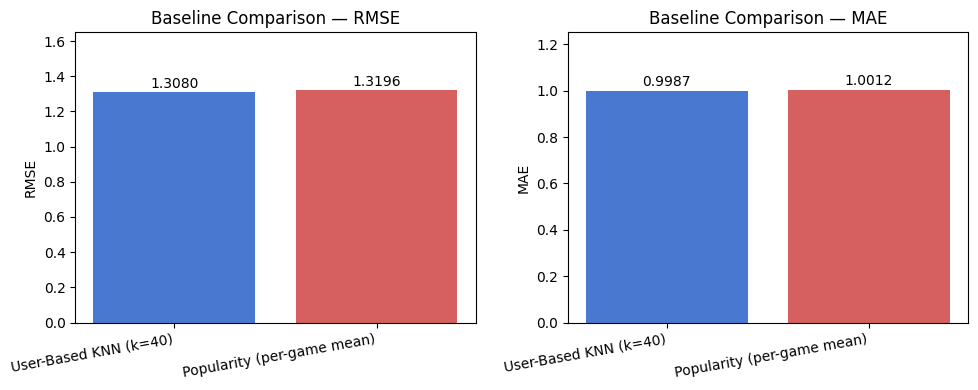

In [20]:
results = pd.DataFrame({
    "Model": ["Popularity (per-game mean)", f"User-Based KNN (k={K})"],
    "RMSE": [rmse_pop, rmse_knn],
    "MAE": [mae_pop,  mae_knn],
})
results = results.sort_values('RMSE').reset_index(drop=True)
display(results.style.format({'RMSE': '{:.4f}', 'MAE': '{:.4f}'}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#4878CF', '#D65F5F']

for ax, metric in zip(axes, ['RMSE', 'MAE']):
    bars = ax.bar(results['Model'], results[metric], color=colors)
    ax.set_title(f'Baseline Comparison — {metric}')
    ax.set_ylabel(metric)
    ax.set_ylim(0, results[metric].max() * 1.25)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    ax.set_xticklabels(results['Model'], rotation=10, ha='right')

plt.tight_layout()
plt.show()